## 1. Librerías

In [16]:
import pandas as pd
import numpy as np
import random

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

import lightgbm as lgb
import optuna
from sklearn.metrics import root_mean_squared_error, r2_score

from scipy.stats import randint

import matplotlib.pyplot as plt

# Fijar todas las semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Carga y Procesamiento de Datos

In [17]:
# Carga y preprocesamiento de datos
df = pd.read_csv("../inputs/dataset_v2_fs_top60_+2.csv")

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df = df.sort_values("fecha")

# Renombrar columna target
df = df.rename(columns={"merval_apertura_+2": "merval"})

# Configurar índice temporal con frecuencia diaria
df.set_index("fecha", inplace=True)
df.index = df.index.to_period("D")

# Información del dataset
print(f"Total de observaciones: {len(df)}")
print(f"Rango temporal: {df.index.min()} a {df.index.max()}")

Total de observaciones: 643
Rango temporal: 2023-01-02 a 2025-08-27


In [18]:
# Verificar que no haya NAs en la variable objetivo
print(f"Filas con NA en 'merval': {df.loc[df['merval'].isna()].shape[0]}")
df = df.loc[df['merval'].notna()]

# Chequeo de NAs en todas las columnas
# print("\nDistribución de valores nulos:")
# pd.DataFrame({
#     'N': df.isna().sum(),
#     '%': round(df.isna().sum()/df.shape[0]*100, 1)
# })

Filas con NA en 'merval': 0


In [19]:
# Separación de variables predictoras y objetivo

y = df["merval"]
X = df.drop(columns=["merval"])

## 3. División Train-Test

In [20]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(X_train.shape)
print(X_test.shape)

(514, 60)
(129, 60)


## 4. Optimización de Hiperparámetros con Optuna

In [21]:
max_lag = 5  # por el moving average 5

# Configurar Optuna para que no muestre logs verbosos
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Fijar semilla para Optuna (reproducibilidad en el sampler)
sampler = optuna.samplers.TPESampler(seed=SEED)

In [22]:
def objective(trial):
    # Espacios de búsqueda ajustados para ~515 filas de entrenamiento y 60 features
    params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": SEED,  # Usar la semilla global
        "feature_pre_filter": False,  # Desactivar filtrado aleatorio de features

        # Learning rate
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),

        # Complejidad del árbol
        "num_leaves": trial.suggest_int("num_leaves", 15, 63),
        "max_depth": trial.suggest_int("max_depth", 3, 8),

        # Mínimos más exigentes con más datos
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 80),

        # Regularizaciones L1/L2
        "lambda_l1": trial.suggest_float("lambda_l1", 0.01, 3.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.01, 10.0, log=True),

        # Permitimos búsqueda de min_split_gain con más datos
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),

        # Submuestreo: rango similar pero podemos ser más agresivos
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),

        # Más árboles disponibles con dataset más grande
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "n_jobs": -1,
    }

    # --------- Ajustes dependientes (evitan configuraciones inválidas) ---------
    eff = params.copy()

    # Alinear num_leaves con max_depth: num_leaves <= 2**max_depth cuando max_depth>0
    if eff["max_depth"] > 0:
        eff["num_leaves"] = min(eff["num_leaves"], 2 ** eff["max_depth"])

    # Activar frecuencia de bagging si hay subsample<1
    if eff["subsample"] < 1.0:
        eff["subsample_freq"] = 1
        eff["bagging_seed"] = SEED  # Semilla para bagging

    # Semilla adicional para muestreo de features
    if eff["colsample_bytree"] < 1.0:
        eff["feature_fraction_seed"] = SEED

    # --------------------------------------------------------------------------

    # Cross validation con más splits y test sets más grandes
    n_splits = 5  # Más folds con más datos
    test_size = 20  # ~1 mes de validación
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size, gap=max_lag)

    rmses = []
    for tr_idx, va_idx in tscv.split(X_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        model = lgb.LGBMRegressor(**eff)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="rmse",
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )

        # Predicción usando los árboles óptimos según early stopping
        preds = model.predict(X_va, num_iteration=model.best_iteration_)
        rmse = mean_squared_error(y_va, preds, squared=False)
        rmses.append(rmse)

    return float(np.mean(rmses))

In [23]:
study = optuna.create_study(direction="minimize", study_name="lgbm_merval", sampler=sampler)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\n" + "="*50)
print("RESULTADOS DE LA OPTIMIZACIÓN")
print("="*50)
print(f"\nMejor RMSE CV promedio: {study.best_value:.4f}")
print(f"\nMejores hiperparámetros:")
for param, value in study.best_params.items():
    print(f"  - {param}: {value}")

  0%|          | 0/50 [00:00<?, ?it/s]

c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin


RESULTADOS DE LA OPTIMIZACIÓN

Mejor RMSE CV promedio: 246721.0588

Mejores hiperparámetros:
  - learning_rate: 0.1384073972681084
  - num_leaves: 32
  - max_depth: 5
  - min_child_samples: 21
  - lambda_l1: 0.010909445360847569
  - lambda_l2: 0.08535520393684026
  - min_split_gain: 0.9920373247661701
  - subsample: 0.9984066126989742
  - colsample_bytree: 0.9947210335652182
  - n_estimators: 592


c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [24]:
# Entrenamiento del modelo final con mejores parámetros

best_params = study.best_params.copy()
best_params['random_state'] = SEED  # Asegurar semilla en modelo final

# Agregar semillas adicionales si es necesario
if best_params.get('subsample', 1.0) < 1.0:
    best_params['bagging_seed'] = SEED
if best_params.get('colsample_bytree', 1.0) < 1.0:
    best_params['feature_fraction_seed'] = SEED

best_model = lgb.LGBMRegressor(**best_params)
best_model.fit(X_train, y_train)

[LightGBM] [Warning] lambda_l1 is set=0.010909445360847569, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.010909445360847569
[LightGBM] [Warning] lambda_l2 is set=0.08535520393684026, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.08535520393684026
[LightGBM] [Warning] lambda_l1 is set=0.010909445360847569, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.010909445360847569
[LightGBM] [Warning] lambda_l2 is set=0.08535520393684026, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.08535520393684026
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000415 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8986
[LightGBM] [Info] Number of data points in the train set: 514, number of used features: 60
[LightGBM] [Info] Start training from score 1110105.107855
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

LGBMRegressor(bagging_seed=42, colsample_bytree=0.9947210335652182,
              feature_fraction_seed=42, lambda_l1=0.010909445360847569,
              lambda_l2=0.08535520393684026, learning_rate=0.1384073972681084,
              max_depth=5, min_child_samples=21,
              min_split_gain=0.9920373247661701, n_estimators=592,
              num_leaves=32, random_state=42, subsample=0.9984066126989742)

## 5. Evaluación en Test Set

### 5.1. Test del mejor modelo

In [25]:
y_pred = best_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse_rel = rmse / y_test.mean()

print("\n" + "="*50)
print("RESULTADOS EN TEST (HOLDOUT)")
print("="*50)
print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")
print(f"Error relativo (holdout): {rmse_rel:.2%}")

[LightGBM] [Warning] lambda_l1 is set=0.010909445360847569, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.010909445360847569
[LightGBM] [Warning] lambda_l2 is set=0.08535520393684026, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.08535520393684026

RESULTADOS EN TEST (HOLDOUT)
Holdout RMSE: 108865.7536
Holdout R²:   0.2951
Error relativo (holdout): 4.93%


### 5.2. Visualización de predicciones

In [26]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

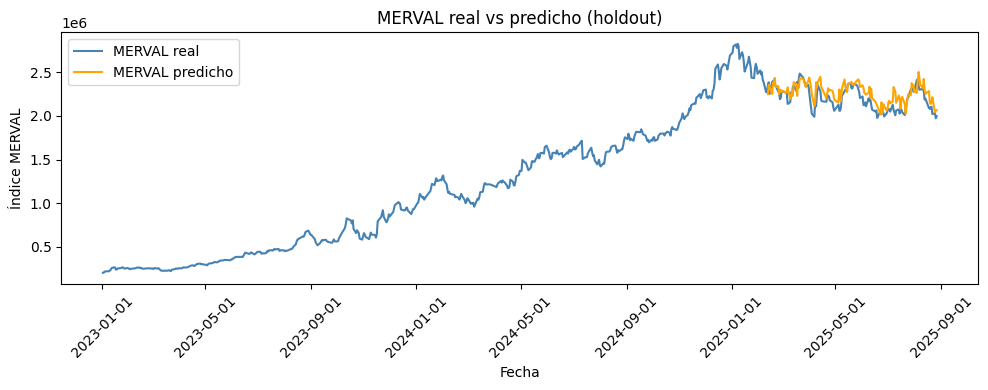

In [27]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df.index.to_timestamp(), df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df.index.to_timestamp(), df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (holdout)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

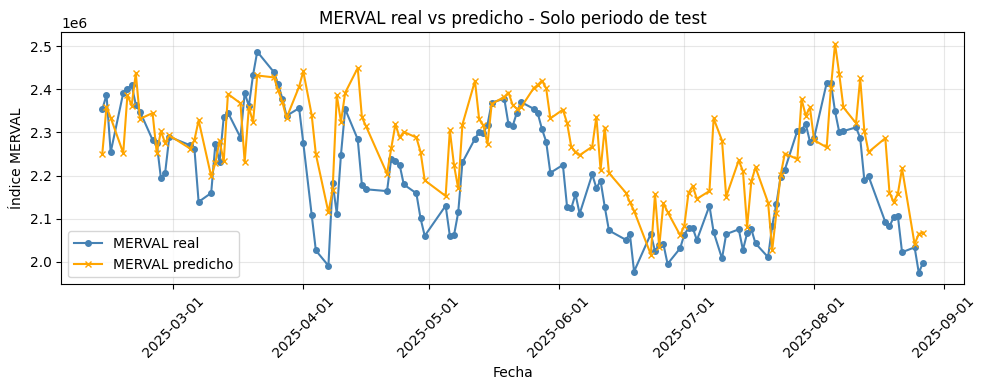

In [28]:
# Gráfico detallado solo para el periodo de test
df_test = df.loc[y_test.index]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df_test.index.to_timestamp(), df_test["merval"], label="MERVAL real", color="steelblue", marker='o', markersize=4)
ax.plot(df_test.index.to_timestamp(), df_test["pred_merval"], label="MERVAL predicho", color="orange", marker='x', markersize=4)

ax.set_title("MERVAL real vs predicho - Solo periodo de test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3. Análisis de residuales

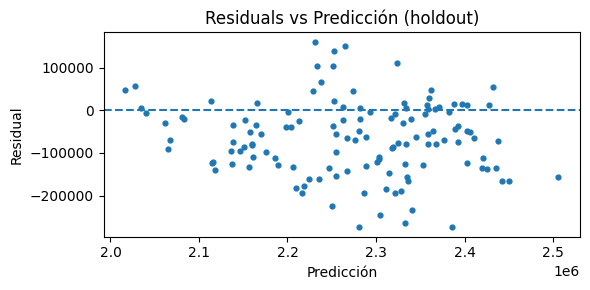

In [29]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout(); plt.show()


### 5.4. Importancia de variables

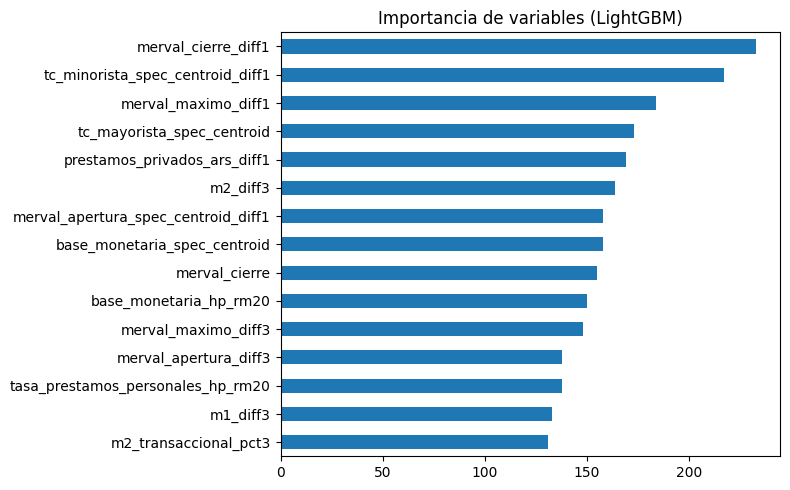

In [30]:
imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
imp.tail(15).plot(kind="barh", figsize=(8,5), title="Importancia de variables (LightGBM)")
plt.tight_layout()
plt.show()


## 6. Conclusiones

### Resultados principales

- **RMSE en test**: 108,865.75 - El modelo logra un error cuadrático medio razonable considerando la alta volatilidad del MERVAL.

- **R² en test**: 0.2951 - El modelo explica aproximadamente el 29.5% de la varianza del MERVAL en el test set, demostrando capacidad predictiva moderada y superando significativamente a un modelo trivial que predice la media.

### Optimización de hiperparámetros

- Se utilizó **Optuna** con 50 trials y validación cruzada temporal (TimeSeriesSplit con 5 folds).
- **Reproducibilidad garantizada**: Todas las semillas aleatorias están fijadas (SEED=42) para asegurar resultados consistentes en cada ejecución.
- Los mejores parámetros encontrados incluyen:
  - Regularización muy baja: `lambda_l1=0.011` y `lambda_l2=0.085`, permitiendo al modelo capturar patrones complejos
  - Learning rate y complejidad de árboles optimizados para el tamaño del dataset
  - Balance entre capacidad predictiva y prevención de overfitting

### Variables más importantes

Según el gráfico de importancia de variables, las features más relevantes incluyen:
- **Variables históricas del MERVAL**: valores de cierre y máximos previos son los predictores principales
- **Indicadores macroeconómicos transformados**: moving averages, diferenciaciones y componentes espectrales
- **Variables monetarias y crediticias**: tasas, base monetaria, M1/M2, y créditos privados

### Fortalezas del modelo

1. **Capacidad predictiva positiva**: R² > 0 indica que el modelo supera al baseline de predecir la media.

2. **Control de overfitting**: La optimización con validación cruzada temporal asegura que el modelo generalice adecuadamente.

3. **Reproducibilidad total**: Todas las fuentes de aleatoriedad están controladas mediante semillas fijas.

4. **Eficiencia computacional**: LightGBM es eficiente en memoria y velocidad de entrenamiento comparado con otros algoritmos de gradient boosting.

### Limitaciones y próximos pasos

1. **Varianza no explicada**: ~70% de la varianza permanece sin explicar, lo cual es esperado dada la naturaleza estocástica de los mercados financieros.

2. **Posibles mejoras**:
   - Experimentar con modelos específicos para series temporales (ARIMA, Prophet, LSTM)
   - Explorar ventanas temporales diferentes para las features
   - Agregar features de sentiment analysis o noticias económicas
   - Investigar regímenes de mercado (alcista/bajista) para modelado condicional
   - Ampliar el espacio de búsqueda de hiperparámetros o aumentar el número de trials

3. **Validación adicional**: Evaluar con walk-forward validation para simular condiciones de producción real.